# Learn for yourself



#Live Coding Session

Before starting today’s lesson, we will have a live coding session to review and reinforce the key concepts covered in our previous class.

In [ ]:
import os

#PATH = 'C:\\Users\\Comp\\Desktop\\Maks\\data'


data = {
'file1.txt': 'this is the content of file  1',
'file2.txt':'content for file 2',

}

def create_folder(path, data_dict):
    os.makedirs(path, exist_ok=True)

    for filename , content in data_dict.items():
        file_path = os.path.join(path, filename)
        print(file_path)
        with open(file_path, 'w') as file:
            file.write(str(content))



create_folder(PATH, data)

#Python Class 8 – Advanced Functions & Scope

In our previous lesson, we were introduced to functions — one of the most powerful tools in Python that allow us to write reusable, organized, and efficient code. We also explored the LEGB rule (Local, Enclosing, Global, Built-in), which defines how Python searches for variables in different scopes.

In today’s class, we’ll continue deepening our understanding of functions by exploring advanced features and real-world use cases. We’ll see how functions can be treated as first-class objects, passed as arguments, returned from other functions, and even nested inside one another.

By the end of this lesson, you’ll be able to:

* Define and use nested functions

* Work confidently with variable scopes and the LEGB rule

* Understand lambda functions for short, inline logic

* Write cleaner, more modular, and reusable Python code

This lesson will help you move from simply writing functions to thinking functionally — an essential skill for any advanced Python developer or data scientist.

Before we get into the details, let’s establish a clearer picture of what functions are all
about. Functions are a nearly universal program-structuring device. You may have come
across them before in other languages, where they may have been called subroutines or
procedures. As a brief introduction, functions serve two primary development roles,
and serve as the basis of other tools:

* Maximizing reuse and minimizing redundancy
* Dividing and conquering
* Implementing object methods



In this lecture, we will begin exploring how to write new functions in Python. Functions
we write behave the same way as the built-ins we’ve already seen: they are called in
expressions, are passed values, and return results. But writing new functions requires
the application of a few additional tools and ideas that haven’t yet been introduced.
Moreover, functions behave very differently in Python than they do in compiled
languages like C.


#Basic Function Tools

As a road map and brief rundown on what we’ll study in this part of the lectures, here are
the basic components and concepts in Python’s function toolbox:

* def creates a function and assigns it to a name
* def is executable code
* return sends a result object back to the caller
* lambda creates a function but returns it as a result


In [ ]:
def greet(name):
    return f"Barev {name}"

message = greet("Rafo")
print(message)

Barev Rafo


In [ ]:
double = lambda x: x * 2
print(double(5), end = '\n\n')

# Lambda used without assignment
print((lambda x: x + 1)(7))

10

8


In [ ]:
double(14)

28

#Advanced Function Tools

In addition, Python functions can leverage more advanced tools like the following,
which we’ll take up after we’ve introduced the basics:

* global declares module-level variables that are to be assigned
* nonlocal declares enclosing-function variables that are to be assigned
* yield sends a result object back to the caller, but remembers where it left
off
* await/async pause a waiting function so that other tasks may run



`global` declares module-level variables

In [ ]:
count = 0

def increment():
    global count
    count += 1

increment()
print(count)

1


In [ ]:
increment()
print(count)

2


`nonlocal` declares enclosing-function variables

In [ ]:
def outer():
    x = 5

    y=7
    def inner():
        nonlocal x
        x += 3
    inner()
    return x

print(outer())

8


`yield` produces values lazily (generator)

In [ ]:
def count_up_to(n):
    for i in range(1, n + 1):
        yield i

for num in count_up_to(3):
    print(num)

1
2
3


`async`/`await` (pausing functions for concurrency)

In [ ]:
import asyncio

async def say_hello():
    print('Barev')
    await asyncio.sleep(2)
    print('Hayer')

# Run async function
await say_hello()
# Output: Barev (waits 2 sec) Hayer

Barev
Hayer


#General Function Concepts

Finally, along the way we’ll explore a handful of core concepts that span functions of
all kinds:

* Arguments are passed by assignment (object reference)
* Arguments are passed by position, unless you say otherwise
* Arguments, return values, and variables are not declared
* Attributes, annotations, and decorators support advanced roles

Arguments are passed by assignment (object reference)

In [ ]:
def modify(lst):
    lst.append(4)

numbers = [1, 2, 3]
modify(numbers)
print(numbers)

[1, 2, 3, 4]


Arguments passed by position (default behavior)

In [ ]:
def greet(first, last):
    return f"Barev {first} {last}"

print(greet("Rafo", "Arakelyan"))  # Positional arguments

Barev Rafo Arakelyan


Arguments, return values, and variables are not declared

In [ ]:
def multiply(a, b):
    result = a * b  # No type declaration
    return result

print(multiply(3, 7))

21


Attributes, annotations, and decorators

In [ ]:
add.__doc__

NameError: name 'add' is not defined

In [ ]:
def add(a: int, b: int) -> int:
    '''
    Function get 2 arguments and return the summation
    a: int
    b: int
    return : int
    '''
    return a + b

print(add.__annotations__)  # Output: {'a': <class 'int'>, 'b': <class 'int'>, 'return': <class 'int'>}
print(add.__doc__)




{'a': <class 'int'>, 'b': <class 'int'>, 'return': <class 'int'>}

    Function get 2 arguments and return the summation
    a: int
    b: int
    return : int
    
Calling square with (5,)
25


In [ ]:
# Example decorator
def debug(func):
    def wrapper(*args, **kwargs):
        print(f"Calling {func.__name__} with {args}")
        return func(*args, **kwargs)
    return wrapper

@debug
def square_name(x):
    return x * x

print(square_name(5))  # Prints debug info then Output: 25

Calling square_name with (5,)
25


##Common Function Attributes

| Attribute         | Description                                         | Example                                                                                                                                        |
| ----------------- | --------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `__name__`        | Name of the function                                | `def foo(): pass; print(foo.__name__)` → `foo`                                                                                                 |
| `__doc__`         | Docstring of the function                           | `def foo(): "I am doc"; pass; print(foo.__doc__)` → `"I am doc"`                                                                               |
| `__annotations__` | Type hints/annotations                              | `def add(a: int, b: int) -> int: return a+b; print(add.__annotations__)` → `{'a': <class 'int'>, 'b': <class 'int'>, 'return': <class 'int'>}` |
| `__defaults__`    | Default argument values                             | `def foo(a=5, b=10): pass; print(foo.__defaults__)` → `(5, 10)`                                                                                |
| `__code__`        | Code object representing the compiled function body | `foo.__code__.co_varnames` → local variable names                                                                                              |
| `__dict__`        | Function’s namespace for custom attributes          | `foo.x = 42; print(foo.__dict__)` → `{'x': 42}`                                                                                                |
| `__closure__`     | Captured variables for closures (nonlocal)          | See closure example below                                                                                                                      |
| `__module__`      | Name of the module where the function is defined    | `print(foo.__module__)` → `'__main__'`                                                                                                         |
| `__qualname__`    | Qualified name (includes nesting)                   | `print(foo.__qualname__)` → `'foo'`                                                                                                            |


Function attributes give you metadata about the function (name, docstring, module, annotations, defaults) and allow you to inspect or even store extra information in the function object.

##`def` Statements

The def statement creates a function object and assigns it to a name. Its general format
and usage is as follows:
    
    def name(arg1, arg2,… argN): # Define a function
        statements               # Function body
    
    name(val1, val2,… valN)      # Call it later in an expression


##`return` Statements

Function bodies often contain one or more return statements that make sense only
inside a def:

    def name(arg1, arg2,… argN):
          …
          return result # The result of the call expression

The Python return statement can show up anywhere in a function body. When reached,
it ends the function call and sends a result back to the caller to serve as the result of the
call expression. The return statement consists of an optional object-value expression
that gives the result. If the value is omitted, return sends back a None by default.


Multiple `return` Statements

In [ ]:
def check_number(x):
    if x > 0:
        return "Positive"
    elif x < 0:
        return "Negative"
    return "Zero"  # default case if others not met

print(check_number(5), end = '\n\n')   # Positive
print(check_number(-3), end = '\n\n')  # Negative
print(check_number(0))                 # Zero

Positive

Negative

Zero


The return statement itself is optional too; if it’s not present, the function exits when
the control flow falls off the end of the function body. Technically, a function without a
return statement also returns the None object automatically, but this return value is
usually ignored at the call, by using a call-expression statement

No `return` → Implicit `None`

In [ ]:
def nothing():
    pass

print(nothing())  # Output: None

None


`yield` vs `return`

**Note**: yield pauses and resumes a function — it’s used in **generators**, which we’ll cover later.

In [ ]:
def count_up_to(n):
    for i in range(1, n + 1):
        yield i  # yields values one by one

# Using the generator
for num in count_up_to(3):
    print(num)


1
2
3


Functions may also contain yield statements used to produce a series of values over
time, as well as await and async for/with statements used to suspend the function’s
execution, but we’ll defer discussion of these more advanced tools until we survey
generator and coroutine topics

# Scope Resolution in Python | LEGB Rule
**Namespaces** : A namespace is a container where names are mapped to objects, they are used to avoid confusions in cases where same names exist in different namespaces. They are created by modules, functions, classes etc.

**Scope** : A scope defines the hierarchical order in which the namespaces have to be searched in order to obtain the mappings of name-to-object(variables). It is a context in which variables exist and from which they are referenced. It defines the accessibility and the lifetime of a variable. Let us take a simple example as shown below:

#Importing modules

In [ ]:
import math
#from math import sin, sinh

from math import sin as ff
ff(47)

0.123573122745224

##Types of Namespaces

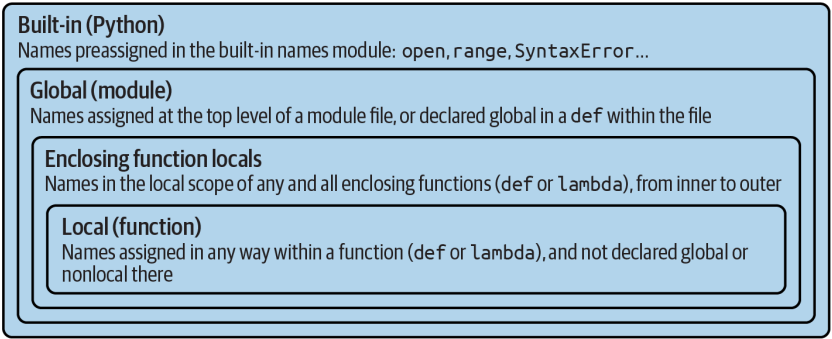

| Namespace     | Created                                  | Example                       |
| ------------- | ---------------------------------------- | ----------------------------- |
| **Built-in**  | When Python starts                       | `print`, `len`, `sum`         |
| **Global**    | When a script or module runs             | Variables in the main file    |
| **Enclosing** | When a function is nested inside another | Used in closures              |
| **Local**     | When a function is called                | Variables inside the function |


In [ ]:
x = "global"  # Global scope

def outer():
    x = "enclosing"  # Enclosing scope

    def inner():
        x = "local"  # Local scope
        print(x)  # Python looks here first → local

    inner()

outer()

local


If `x = "local"` was commented out, Python would look into `enclosing`, then `global`, then `built-in`.

##The `global` and `nonlocal` Keywords

They allow you to modify variables in other scopes.

On the other hand, sometimes you do want the same variable to be available to multiple functions. Such a variable is called a global variable. You have to be careful using global variables, especially in larger programs. Here is a short example:

Example: `global`

In [ ]:
count = 0  # global variable

def increment():
    global count
    count += 1

increment()
print(count)

1


Example: `nonlocal`

In [ ]:
def outer():
    x = 5
    def inner():
        nonlocal x  # refers to outer()'s x
        x += 1
        print(x)
    inner()
    print(x)

outer()

6
6


Without `nonlocal`, the `inner()` function would create its own local `x` and the outer one would not change.

In [ ]:
pi = 'global pi variable'

def outer():
  pi = 'outer pi variable'
  def inner():
    nonlocal pi
    pi = "local pi variable"
    print(pi)
  inner()
  print(pi)

outer()
print(pi)

local pi variable
local pi variable
global pi variable


When we use `nonlocal` statement, `inner()`'s `pi` is now also `outer()`'s `pi`.

## Local, Enclosed, Global and Built-in Scopes
The final check can be done by importing pi from math module and commenting the global, enclosed and local pi variables.

In [ ]:
from math import pi

pi = 'global pi variable'
def outer():
    pi = 'outer pi variable'
    def inner():
        pi = 'inner pi variable'
        print(pi)
    inner()

outer()
print(pi)

inner pi variable
global pi variable


##Summary Table

| Scope     | Example of Where It Exists | Accessed By   | Modified Using |
| --------- | -------------------------- | ------------- | -------------- |
| Local     | Inside a function          | Automatically | Directly       |
| Enclosing | Inside a nested function   | Automatically | `nonlocal`     |
| Global    | At module level            | Automatically | `global`       |
| Built-in  | Python system-level names  | Automatically | Can’t modify   |


## In other words
A namespace is a place where names live,
and a scope is where Python looks for them when you use them.

# Lambda functions (anonymous)

In addition to def, you can make a new function with the lambda expression. It’s coded
and might be used like this:

    name = lambda arg1, arg2,… argN: expression
    
    name(val1, val2,… valN)

Like def, lambda makes a new function object to be called later. It begins with the
word lambda, followed by an arguments-list header that works the same as in def but
is coded without parentheses. Unlike def, the code after the : in lambda is a single
expression—it cannot contain statements and is the implied body and return value of the
function that lambda makes. We don’t need to say return in a lambda (and we can’t).    

In [ ]:
# A lambda function that adds 10 to the number passed
#  in as an argument, and print the result
x = lambda a: a + 10
def xx(a): return a + 10

print(x(5))
print(xx(5))

15
15


In [ ]:
#A lambda function that multiplies argument a with argument b
#  and print the result
x = lambda a, b: a * b
print(x(5, 6))

30


The power of lambda is better shown when you use them as **an anonymous function inside another function**.

Say you have a function definition that takes one argument, and that argument will be multiplied with an unknown number.

In [ ]:
def myfunc(n):
  return lambda a : a ** n

mydoubler = myfunc(n=2)
#mydoubler = lambda a : a ** 2
print(mydoubler(a=11))

121


Sort a dictionary

In [ ]:
some_dict = {'A':1, 'B': 200, 'C':50}
sorted(some_dict)

['A', 'B', 'C']

In [ ]:
help(sorted)

Help on built-in function sorted in module builtins:

sorted(iterable, /, *, key=None, reverse=False)
    Return a new list containing all items from the iterable in ascending order.

    A custom key function can be supplied to customize the sort order, and the
    reverse flag can be set to request the result in descending order.



In [ ]:
sorted(some_dict.items())

[('A', 1), ('B', 200), ('C', 50)]

In [ ]:
# sorted(some_dict.items())
sorted(some_dict.items(), key=lambda x: x[1], reverse=True)

[('B', 200), ('C', 50), ('A', 1)]

In [ ]:
def my_func(x): return x[1]
sorted(some_dict.items(), key=my_func, reverse=True)

[('B', 200), ('C', 50), ('A', 1)]

`key=lambda x: x[1]`

* Here, `x` represents each tuple (key, value).

* `x[1]` accesses the second element of the tuple — the value.

* So the sort uses values to determine order.

In [ ]:
lst = [('Rafo', 'Arakelyan', 136),
       ('Poghos', 'Poghosyan', 15),
       ('Petros', 'Petrosyan', 65)]

sorted(lst, key=lambda a : a[-1], reverse=True)

[('Rafo', 'Arakelyan', 136),
 ('Petros', 'Petrosyan', 65),
 ('Poghos', 'Poghosyan', 15)]

`key=lambda a: a[-1]`

* `a` is each tuple in the list.

* `a[-1]` accesses the last element of the tuple (the number).

* So the sorting is done by the number field.

##Why `lambda` function is called 'anonymous'

Also unlike def, lambda does not itself assign the new function to a name, but simply
returns it as the result of the whole lambda expression. This snippet manually assigns
the function to a name through which it is called, but that’s optional: the result might
also be saved in another object or passed for use elsewhere. Because of this, lambda is
usually called an “anonymous” function—one that’s unnamed.


##Anonymous usage (no name at all)

Here:

* The lambda creates a temporary function.

* It’s called immediately with (4, 5).

* It has no name — so it’s anonymous.

In [ ]:
print((lambda x, y: x * y)(4, 5))

20


##Passing a lambda as an argument

You’ll often see lambdas used where you need to pass a small function to another function:

In [ ]:
numbers = [1, 2, 3, 4, 5]
squared = map(lambda x: x ** 2, numbers)

print(list(squared))

[1, 4, 9, 16, 25]


##Summary Table

| Type     | How It’s Defined              | Has a Name?                     | Example                       |
| -------- | ----------------------------- | ------------------------------- | ----------------------------- |
| `def`    | Function definition statement | ✅ Yes                           | `def add(x, y): return x + y` |
| `lambda` | Inline anonymous function     | ❌ No (unless manually assigned) | `lambda x, y: x + y`          |


#Polymorphism in Python

As we just saw, the very meaning of the expression x * y in our simple times function
depends completely upon the kinds of objects that x and y are—thus, the same function
can perform multiplication in one instance and repetition in another. Python leaves it up
to the objects to do something reasonable for the syntax. Really, * is just a dispatch
mechanism that routes control to the objects being processed.


Functions with Polymorphic Behavior

In [ ]:
def add(x, y):
    return x + y

print(add(2, 3), end = '\n\n')                 # Numbers: 5
print(add("Barev ", "Hayer"), end = '\n\n')    # Strings: Barev Hayer
print(add([1, 2], [3, 4]))                     # Lists: [1, 2, 3, 4]

5

Barev Hayer

[1, 2, 3, 4]


Explanation:

* The + operator behaves differently depending on the types:

* Numbers → arithmetic addition

* Strings → concatenation

* Lists → concatenation

This is **polymorphism** in action: the same operation adapts to the types of objects it’s given.